# Galaxy Redshift Prediction with Vision Transformer

# 1. Setup

In [1]:
import os
import sys
import csv
import copy

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

import h5py
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from torchvision.models import VisionTransformer
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.data_loader import get_dataloaders, BAND_MEAN, BAND_STD
from src.metrics import redshift_metrics, evaluate_by_bin
from src.utils import (set_seed, get_device, SPLIT_COLORS,
                       plot_pred_vs_true, plot_binned_performance,
                       full_evaluation, full_evaluation_extended,
                       plot_learning_curves)
from src.models.vit import get_vit_regressor

%load_ext autoreload
%autoreload 2

In [2]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


# 2. Data

In [15]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)

TRAIN_PATH = os.path.join(BASE_DATA, "5x127x127_training_with_morphology.hdf5")
VAL_PATH = os.path.join(BASE_DATA, "5x127x127_validation_with_morphology.hdf5")
TEST_PATH = os.path.join(BASE_DATA, "5x127x127_testing_with_morphology.hdf5")

EXCLUDE = {"image", "specz_redshift", "specz_redshift_err", "specz_flag_homogeneous"}

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    batch_size=32,
    num_workers=0,
    resize=224,
)

imgs, labels = next(iter(train_loader))
print(f"images : {imgs.shape} | dtype: {imgs.dtype} | NaN: {imgs.isnan().any().item()}")
print(f"labels : min={labels.min():.3f}  max={labels.max():.3f}  mean={labels.mean():.3f}")
print(f"per-band mean: {imgs.mean(dim=[0, 2, 3]).numpy().round(3)}")
print(f"per-band std : {imgs.std(dim=[0, 2, 3]).numpy().round(3)}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
images : torch.Size([32, 5, 224, 224]) | dtype: torch.float32 | NaN: False
labels : min=0.052  max=1.316  mean=0.366
per-band mean: [0.055 0.067 0.084 0.073 0.074]
per-band std : [0.795 0.979 1.302 1.173 1.104]


# 3. Model Architecture

In [5]:
SAVE_PATH = os.path.join(BASE_MODELS, "vit_redshift_regressor_best.pth")
RESUME_PATH = os.path.join(BASE_MODELS, "vit_latest.pth")
NUM_EPOCHS = 50
patience = 25

model = get_vit_regressor(5).to(device)
criterion = nn.SmoothL1Loss(beta=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])
scaler = torch.amp.GradScaler() if str(device) == "cuda" else None

if str(device) == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

print(f"Device          : {device}")
print(f"Total params    : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Mixed precision : {'enabled (GradScaler)' if scaler else 'disabled (CPU)'}")

Device          : mps
Total params    : 86,191,873
Trainable params: 86,191,873
Mixed precision : disabled (CPU)


# 4. Model Training

In [ ]:
def train_epoch(model, loader, optim, criterion, device, scaler=None, accum=2):
    model.train()
    total_loss = 0.0
    running_loss = 0.0
    pbar = tqdm(loader, desc="Train", leave=True)
    optim.zero_grad(set_to_none=True)

    for i, (imgs, targets) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).view(-1, 1)

        autocast_device = "cuda" if str(device) == "cuda" else "cpu"
        with torch.amp.autocast(autocast_device, enabled=(scaler is not None)):
            preds = model(imgs)
            loss = criterion(preds, targets) / accum

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (i + 1) % accum == 0:
            if scaler:
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optim)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
            optim.zero_grad(set_to_none=True)

        batch_loss = loss.item() * accum
        total_loss += batch_loss
        running_loss = total_loss / (i + 1)
        gpu_gb = f"{torch.cuda.memory_allocated(device)/1e9:.1f}" if str(device) == "cuda" else "N/A"

        pbar.set_postfix(ordered_dict={
            "batch_loss" : f"{batch_loss:.4f}",
            "avg_loss" : f"{running_loss:.4f}",
            "best_val" : f"{best_loss:.4f}" if "best_loss" in globals() else "N/A",
            "lr" : f"{optim.param_groups[0]['lr']:.1e}",
            "GPU_GB" : gpu_gb,
        })

    if (i + 1) % accum != 0:
        if scaler:
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optim)
            scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
        optim.zero_grad(set_to_none=True)

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).view(-1, 1)

            autocast_device = "cuda" if str(device) == "cuda" else "cpu"
            with torch.amp.autocast(autocast_device, enabled=(str(device) == "cuda")):
                outputs = model(imgs)
                loss = criterion(outputs, targets)

            total_loss += loss.item() * imgs.size(0)
            all_preds.append(outputs.cpu().float().numpy())
            all_targets.append(targets.cpu().float().numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()

    # ← delegates to src/metrics.py instead of computing inline
    metrics = redshift_metrics(all_targets, all_preds)
    metrics["loss"] = total_loss / len(loader.dataset)

    return metrics

In [9]:
start_epoch = 0
train_losses = []
val_losses = []
best_loss = float("inf")
no_improve = 0

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt and scaler and ckpt["scaler_state_dict"]:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_loss = ckpt.get("best_val_loss", float("inf"))
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    no_improve = ckpt.get("no_improve", 0)
    print(f"Resumed epoch {start_epoch}, best: {best_loss:.4f}, no_improve: {no_improve}")

checkpoint_template = {
    "model_params"    : {
        "in_channels": 5,
        "image_size" : 224,
        "patch_size" : 16,
        "num_layers" : 12,
        "num_heads" : 12,
        "hidden_dim" : 768,
        "mlp_dim" : 3072,
    },
    "mean" : BAND_MEAN.tolist() if hasattr(BAND_MEAN, "tolist") else list(BAND_MEAN),
    "std" : BAND_STD.tolist() if hasattr(BAND_STD, "tolist") else list(BAND_STD),
    "batch_size" : 32,
    "criterion" : "SmoothL1Loss(beta=0.1)",
    "task" : "redshift_regression",
    "torch_version" : torch.__version__,
    "optimizer_config": {
        "lr" : 3e-4,
        "weight_decay" : 0.05,
        "eta_min" : 1e-6,
        "T_max" : 45,
        "warmup_epochs": 5,
        "patience" : patience,
        "accum_steps" : 2,
    },
}

CSV_PATH = os.path.join(BASE_MODELS, "vit_training_metrics.csv")
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow([
            "epoch", "train_loss", "val_loss", "val_mae", "val_rmse",
            "val_r2", "val_nmad", "val_outlier_pct",
            "within_0.1z", "within_0.05z", "val_bias",
            "gap", "best_val_loss", "no_improve", "is_best", "lr"
        ])

print(f"Training from epoch {start_epoch}/{NUM_EPOCHS}")

Resumed epoch 50, best: 0.0485, no_improve: 4
Training from epoch 50/50


In [10]:
for epoch in range(start_epoch, 50):
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, device, scaler)
    val_metrics = evaluate(model, val_loader, criterion, device)
    val_loss = val_metrics['loss']
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step()

    is_best = val_loss < best_loss * 0.999

    latest_ckpt = copy.deepcopy(checkpoint_template)
    latest_ckpt.update({
        'model_state_dict' : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch' : epoch,
        'best_val_loss' : best_loss,
        'no_improve' : no_improve,
        'train_losses' : train_losses.copy(),
        'val_losses' : val_losses.copy(),
        **({'scaler_state_dict': scaler.state_dict()} if scaler else {})
    })
    torch.save(latest_ckpt, "vit_latest.pth")

    with open(csv_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            round(tr_loss, 6),
            round(val_loss, 6),
            round(val_metrics['mae'], 6),
            round(val_metrics['rmse'], 6),
            round(val_metrics['r2'], 6),
            round(val_metrics['nmad'], 6),
            round(val_metrics['outlier_pct'], 4),
            round(val_metrics['within_0.1z'], 4),
            round(val_metrics['within_0.05z'], 4),
            round(best_loss, 6),
            no_improve,
            is_best,
            current_lr,
            round(tr_loss - val_loss, 6),
            round(val_metrics['bias'], 6)
        ])

    clear_output(wait=True)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'b-', label='Train')
    plt.plot(val_losses, 'r-', label='Val')
    plt.yscale('log')
    plt.legend()
    plt.title(f'Epoch {epoch+1} | Best: {best_loss:.4f}')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.text(0.1, 0.80, f"MAE:          {val_metrics['mae']:.4f}", fontsize=12)
    plt.text(0.1, 0.70, f"RMSE:         {val_metrics['rmse']:.4f}", fontsize=12)
    plt.text(0.1, 0.60, f"R2:           {val_metrics['r2']:.4f}", fontsize=12)
    plt.text(0.1, 0.50, f"NMAD:         {val_metrics['nmad']:.4f}", fontsize=12)
    plt.text(0.1, 0.40, f"Outlier%:     {val_metrics['outlier_pct']:.2f}%", fontsize=12)
    plt.text(0.1, 0.30, f"Within 0.1z:  {val_metrics['within_0.1z']*100:.1f}%", fontsize=12)
    plt.text(0.1, 0.20, f"Within 0.05z: {val_metrics['within_0.05z']*100:.1f}%",fontsize=12)
    plt.text(0.1, 0.10, f"No improve:   {no_improve} / {patience}", fontsize=12)
    plt.text(0.1, 0.00, f"LR:           {current_lr:.2e}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}: Train {tr_loss:.4f} | Val {val_loss:.4f} | "
          f"MAE {val_metrics['mae']:.4f} | NMAD {val_metrics['nmad']:.4f} | "
          f"Outlier% {val_metrics['outlier_pct']:.2f} | R2 {val_metrics['r2']:.4f} | "
          f"LR {current_lr:.2e}")

    if is_best:
        best_loss = val_loss
        no_improve = 0
        ckpt = copy.deepcopy(checkpoint_template)
        ckpt.update({
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch' : epoch,
            'best_val_loss' : best_loss,
            'no_improve' : 0,
            'train_losses' : train_losses.copy(),
            'val_losses' : val_losses.copy(),
            'val_metrics'         : {
                'loss' : val_loss,
                'rmse' : val_metrics['rmse'],
                'mae' : val_metrics['mae'],
                'bias' : val_metrics['bias'],
                'r2' : val_metrics['r2'],
                'nmad' : val_metrics['nmad'],
                'outlier_pct' : val_metrics['outlier_pct'],
                'within_0.1z' : val_metrics['within_0.1z'],
                'within_0.05z': val_metrics['within_0.05z'],
            },
            **({'scaler_state_dict': scaler.state_dict()} if scaler else {})
        })
        torch.save(ckpt, SAVE_PATH)
        print(f"NEW BEST: {best_loss:.4f}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"EARLY STOP at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"vit_epoch_{epoch+1:02d}.pth")

print(f"Training complete. Best loss: {best_loss:.4f}")

Training complete. Best loss: 0.0485


# 5. Evaluation

In [11]:
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

with h5py.File(TEST_PATH, 'r') as f:
    flags = f['specz_flag_homogeneous'][:].astype(bool)
    y_true = f['specz_redshift'][:].astype(np.float32)[flags]

all_preds = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc="Test inference"):
        imgs = imgs.to(device)
        preds = model(imgs).cpu().float().numpy().flatten()
        all_preds.append(preds)
y_pred = np.concatenate(all_preds).flatten()

# NaN/Inf guard
n_total = len(y_pred)
finite_mask = np.isfinite(y_pred) & np.isfinite(y_true)
n_bad = int((~finite_mask).sum())

if n_bad > 0:
    print(f"{n_bad:,} non-finite predictions ({n_bad/n_total*100:.3f}% of test set)")
    print(f"Filtering before evaluation — {n_total - n_bad:,} galaxies remain.")
    y_pred = y_pred[finite_mask]
    y_true = y_true[finite_mask]
else:
    print(f"No NaN/Inf found — all {n_total:,} predictions are finite.")

# Primary range: 0.0 ≤ z ≤ 2.5
mask_primary = (y_true >= 0.0) & (y_true <= 2.5)
y_pred_primary = y_pred[mask_primary]
y_true_primary = y_true[mask_primary]

print(f"\nPrimary range (0.0–2.5): {mask_primary.sum():,} galaxies")
print(f"y_pred  min={y_pred_primary.min():.4f}  max={y_pred_primary.max():.4f}  "
      f"mean={y_pred_primary.mean():.4f}  std={y_pred_primary.std():.4f}")
print(f"y_true  min={y_true_primary.min():.4f}  max={y_true_primary.max():.4f}  "
      f"mean={y_true_primary.mean():.4f}")

Test inference:   0%|          | 0/1279 [00:00<?, ?it/s]

No NaN/Inf found — all 40,914 predictions are finite.

Primary range (0.0–2.5): 40,039 galaxies
y_pred  min=-0.0199  max=3.7385  mean=0.5561  std=0.4811
y_true  min=0.0108  max=2.4992  mean=0.5387


In [19]:
np.save(os.path.join(BASE_MODELS, "vit_ypred.npy"), y_pred_primary)
np.save(os.path.join(BASE_MODELS, "vit_ytrue.npy"), y_true_primary)

In [13]:
print(f"\n=== Primary range (0.0 ≤ z ≤ 2.5) — N={mask_primary.sum():,} ===")
test_metrics = redshift_metrics(y_pred_primary, y_true_primary)
for key, value in test_metrics.items():
    print(f"  {key:<28}: {value:.4f}")

evaluate_by_bin(y_true_primary, y_pred_primary,
                bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])


=== Primary range (0.0 ≤ z ≤ 2.5) — N=40,039 ===
  rmse                        : 0.1776
  mae                         : 0.0608
  bias                        : 0.0026
  r2                          : 0.8434
  nmad                        : 0.0230
  outlier_pct                 : 3.2468
  cat_outlier_pct             : 1.6334
  three_sigma_outlier_pct     : 8.3968
  outlier_abs_pct             : 1.0015
  lsst_cat_outlier_pct        : 1.0015
  within_0.1z                 : 0.9475
  within_0.05z                : 0.8693

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.1293   0.0197      1.88%       0.39%   0.0033
0.5–1.0       14,815   0.1811   0.0223      3.21%       1.21%   0.0059
1.0–1.5        2,069   0.3601   0.0591     11.65%       4.01%   0.0059
1.5–2.0          938   0.3327   0.0643     13.97%       2.24%   0.0067
2.0–2.5        1,047   0.3812   0.0397     10.03%       4

,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.129330,0.019732,1.884701,0.388027,0.003342
1,0.5–1.0,14815,0.181084,0.022257,3.212960,1.214985,0.005871
2,1.0–1.5,2069,0.360129,0.059091,11.648139,4.011600,0.005931
3,1.5–2.0,938,0.332707,0.064302,13.965885,2.238806,0.006716
4,2.0–2.5,1047,0.381170,0.039711,10.028653,4.584527,0.010899


# 6. Visualizations

Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/vit_scatter.png


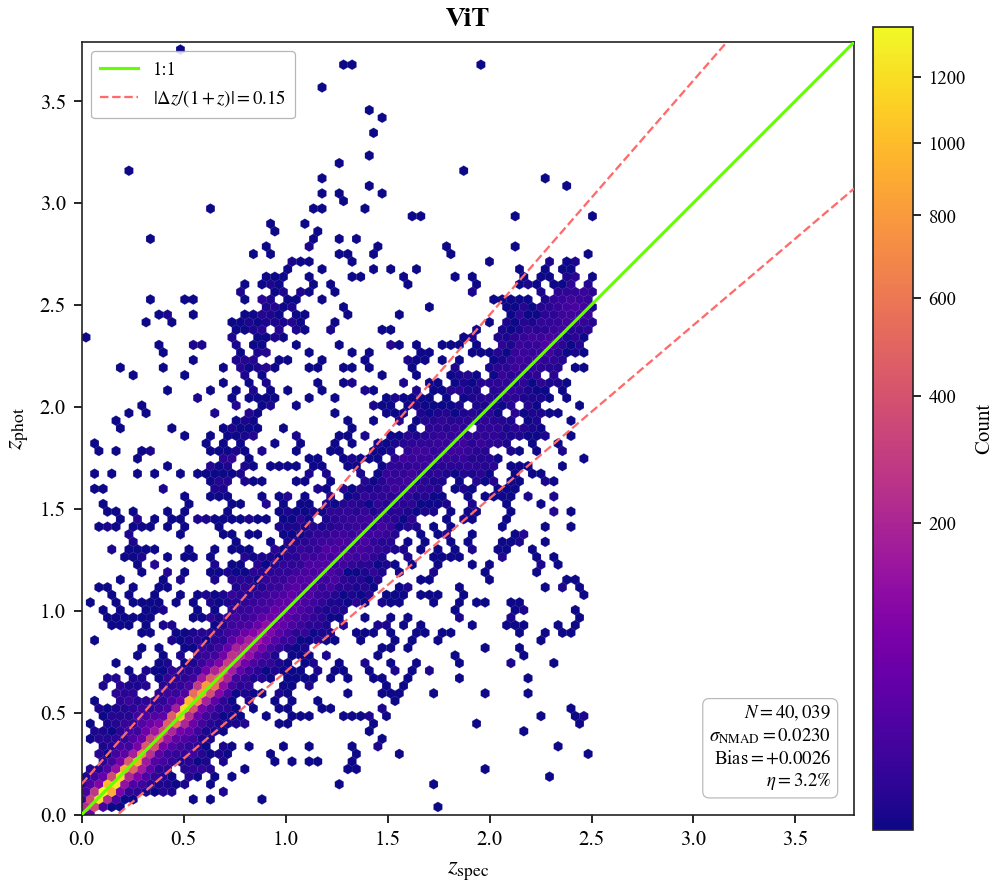

In [23]:
plot_pred_vs_true(
    y_true_primary,
    y_pred_primary,
    name="ViT",
    save_path=os.path.join(BASE_REPORTS, "vit_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/vit_binned.png


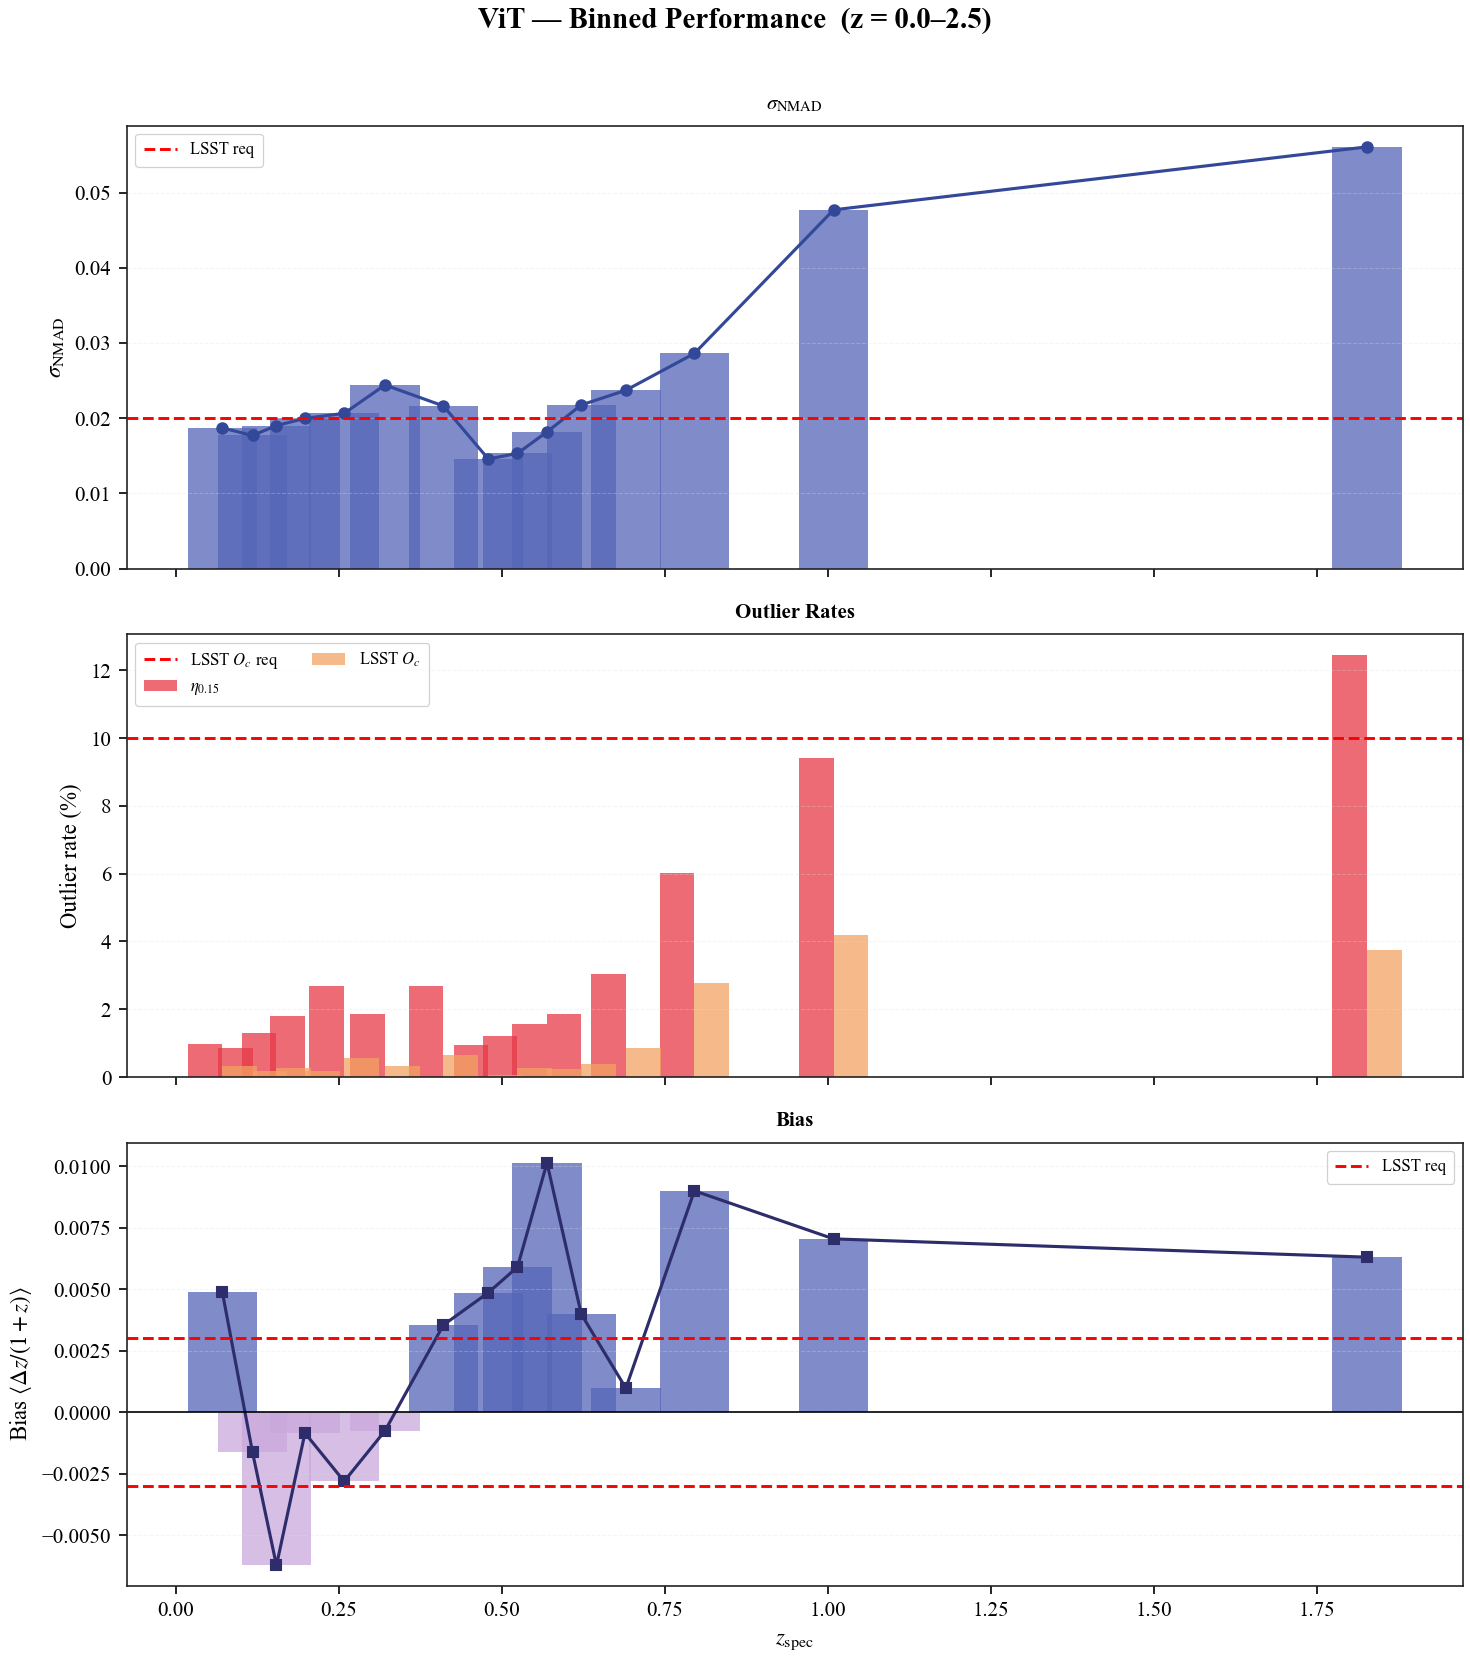

In [24]:
plot_binned_performance(
    y_true_primary,
    y_pred_primary,
    name="ViT",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "vit_binned.png"),
)

Figure saved → /Users/arpinejanunts/Desktop/Capstone/reports/vit_full_eval.png


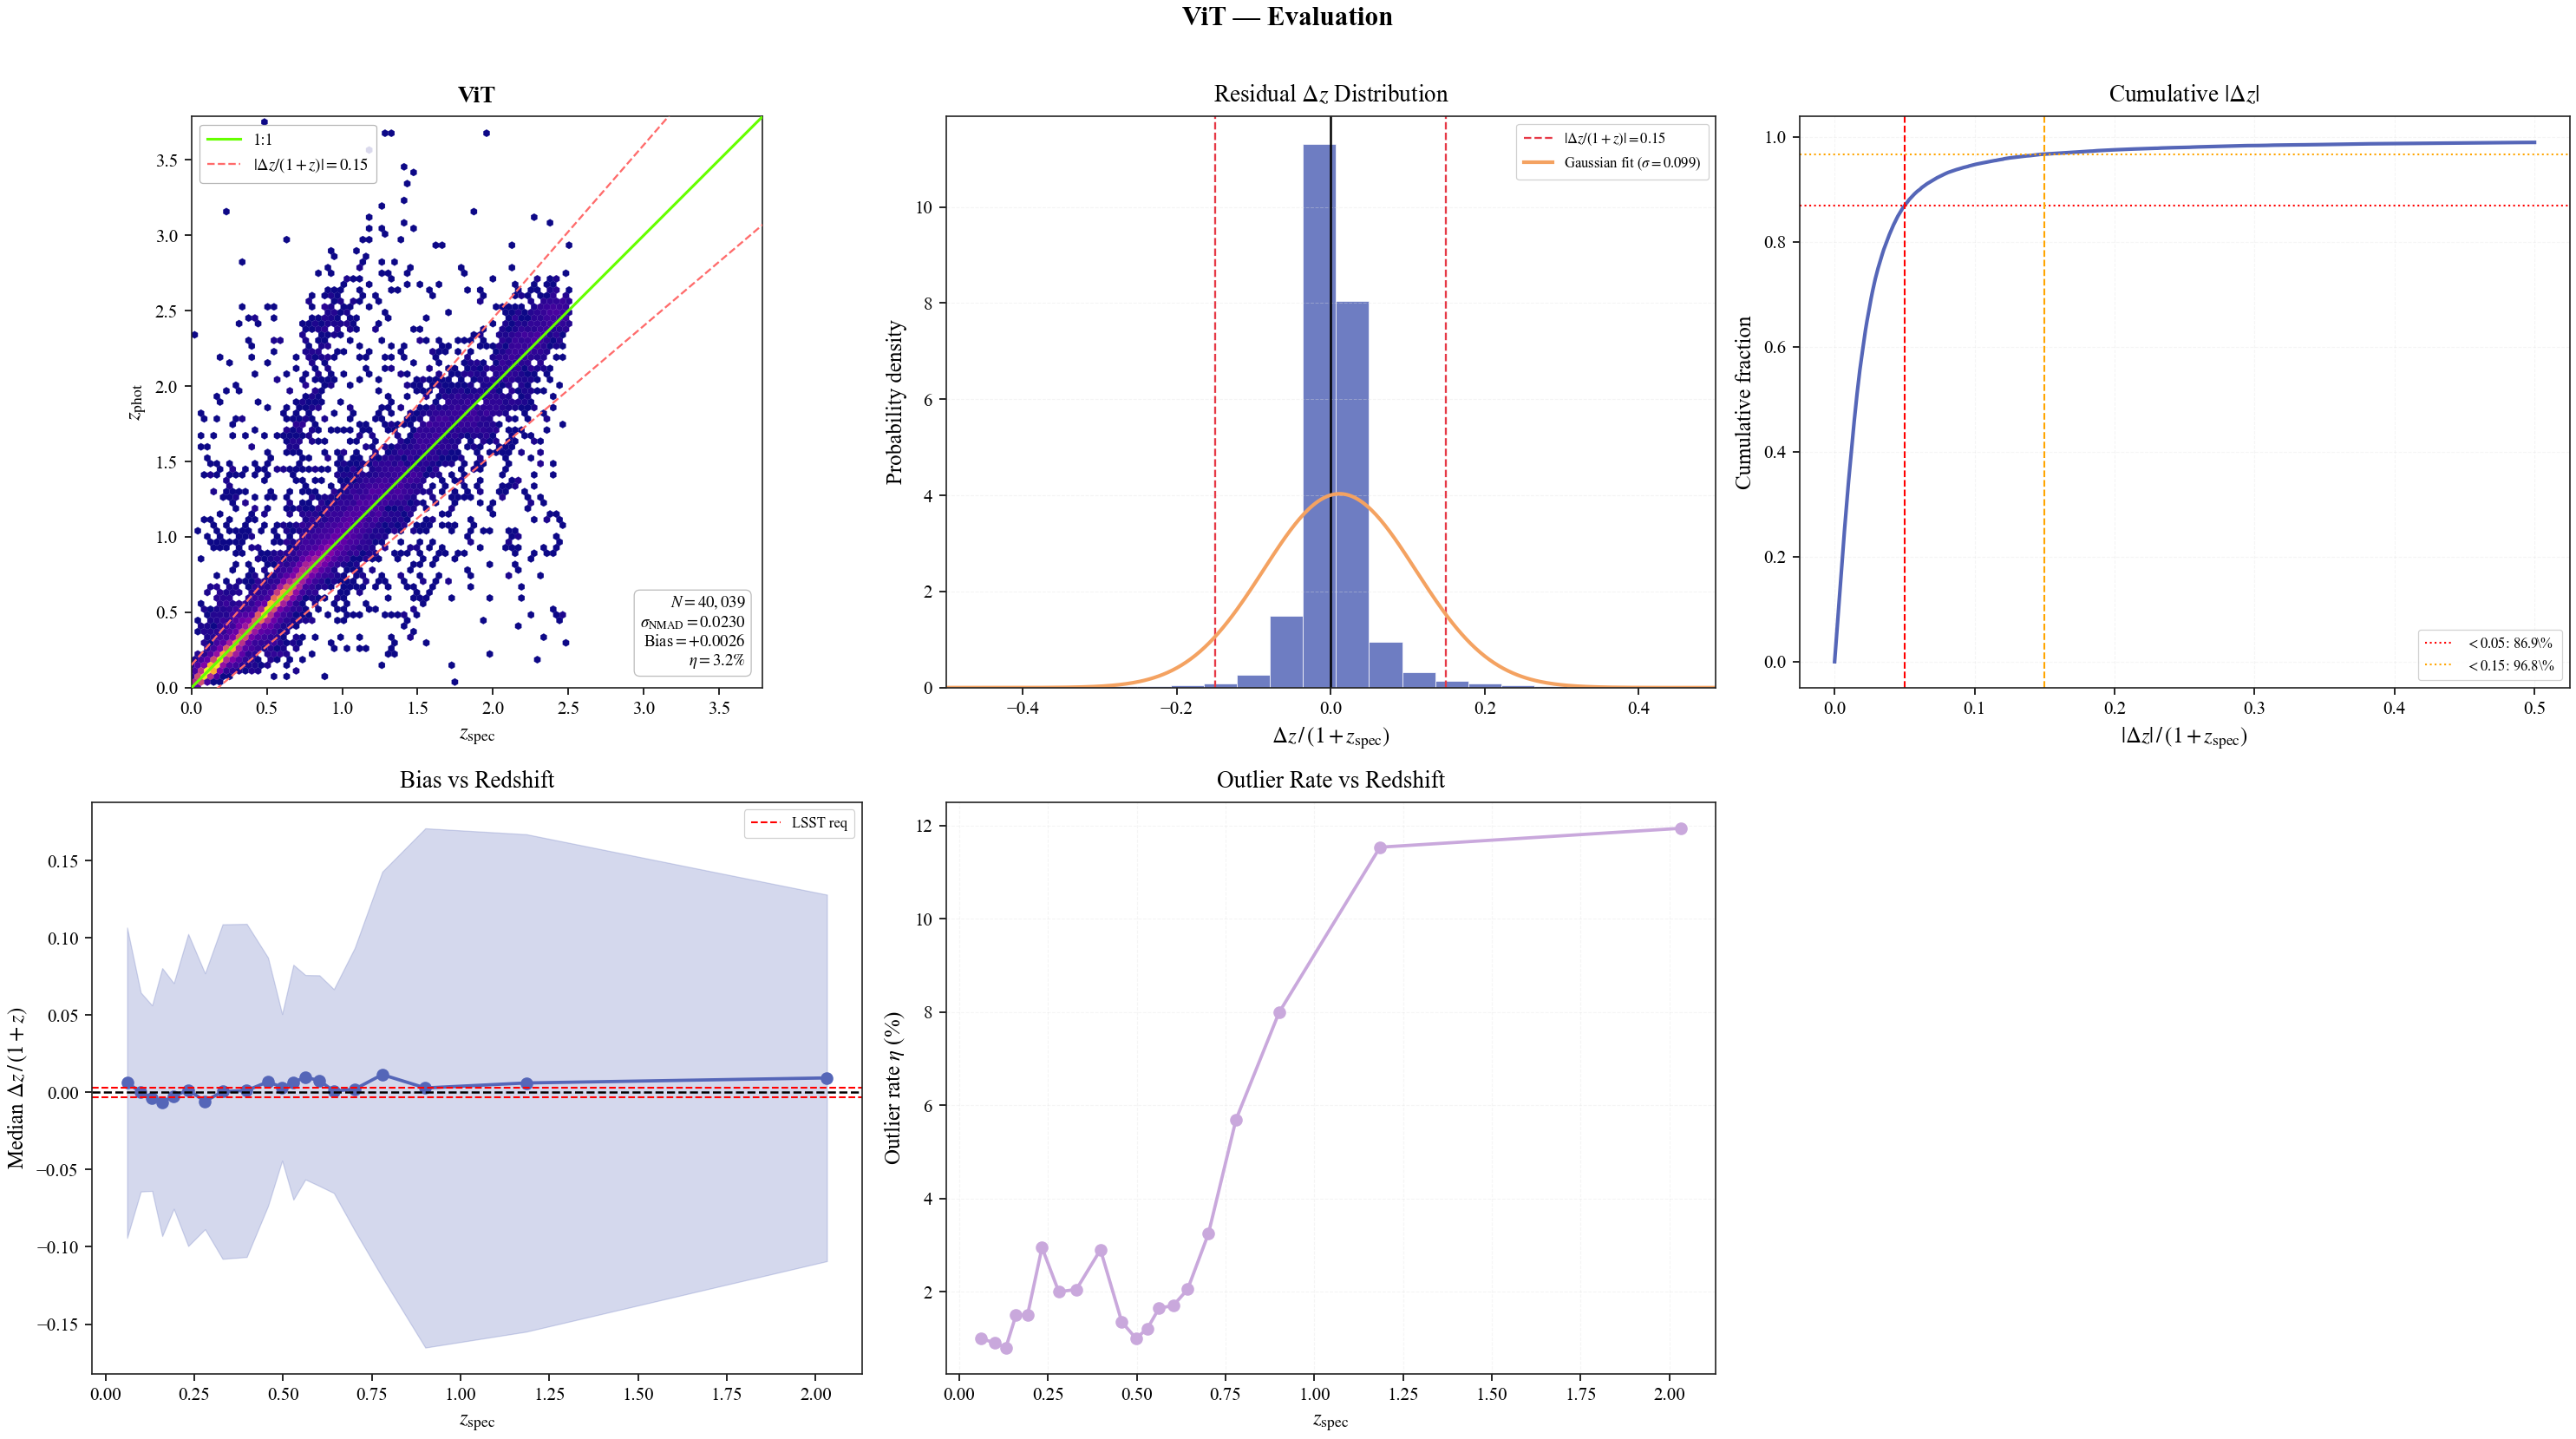

In [25]:
full_evaluation(
    name="ViT",
    y_true=y_true_primary,
    y_pred=y_pred_primary,
    save_path=os.path.join(BASE_REPORTS, "vit_full_eval.png"),
)